# Import Library

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.express as px
import plotly.io as pio

try:
    import google.colab
    pio.renderers.default = 'colab'
except ImportError:
    pio.renderers.default = 'notebook_connected'
print(f"Renderer set to: {pio.renderers.default}")

Renderer set to: colab


# Load Dataset

In [ ]:
# Muat Data
# Pastikan file 'Sales_Transaction_Cleaned.csv' ada di direktori yang sama
df = pd.read_csv('Sales_Transaction_Cleaned.csv')

# Menampilkan jumlah data yang di load
print(f"Jumlah baris data yang berhasil dimuat: {len(df)}")

Jumlah baris data yang berhasil dimuat: 527765


In [ ]:
# Menampilkan 5 baris data pertama
print(df.head())

   InvoiceNo InvoiceDate StockCode                          Description  \
0     581482  2019-12-09     22485        Set Of 2 Wooden Market Crates   
1     581475  2019-12-09     22596  Christmas Star Wish List Chalkboard   
2     581475  2019-12-09     23235             Storage Tin Vintage Leaf   
3     581475  2019-12-09     23272    Tree T-Light Holder Willie Winkie   
4     581475  2019-12-09     23239    Set Of 4 Knick Knack Tins Poppies   

   UnitPrice  Quantity  CustomerID         Country    Sales Invoice_Day  
0      18.74      12.0     17490.0  United Kingdom  257.640  2019-12-09  
1      10.65      26.0     13069.0  United Kingdom  272.745  2019-12-09  
2      11.53      12.0     13069.0  United Kingdom  138.360  2019-12-09  
3      10.65      12.0     13069.0  United Kingdom  127.800  2019-12-09  
4      11.94       6.0     13069.0  United Kingdom   71.640  2019-12-09  


In [ ]:
# Menampilkan statistik deskriptif
print(df.describe())

           InvoiceNo      UnitPrice       Quantity     CustomerID  \
count  527765.000000  527765.000000  527765.000000  527764.000000   
mean   559978.929626      12.286417       6.900020   15231.626733   
std     13434.267080       3.302872       7.560179    1716.522182   
min    536365.000000       6.340000       1.000000   12004.000000   
25%    547903.000000      10.990000       1.000000   13813.000000   
50%    560710.000000      11.940000       3.000000   15159.000000   
75%    571850.000000      14.090000      11.000000   16729.000000   
max    581587.000000      18.740000      26.000000   18287.000000   

               Sales  
count  527765.000000  
mean       77.665359  
std        80.273004  
min         5.130000  
25%        17.170000  
50%        43.830000  
75%       119.400000  
max       272.745000  


# Capping Outlier Menggunakan Metode Interquartile Range (IQR)

In [ ]:
def cap_outliers_iqr(df, column):
    """
    Menerapkan capping (pembatasan) outlier menggunakan metode IQR.
    Nilai yang lebih besar dari batas atas atau lebih kecil dari batas bawah
    akan diubah menjadi nilai batas tersebut.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Batas atas dan bawah
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    # Menerapkan Capping
    # Batasi nilai minimum ke 0 atau lower_bound jika lower_bound > 0
    # Karena fitur seperti Quantity, Sales, dan AvgTransactionValue tidak mungkin negatif.
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    df[column] = np.where(df[column] < max(0, lower_bound), max(0, lower_bound), df[column])

    return df

# Feature Engineering & Penanganan Outlier untuk Customer Clustering

In [ ]:
customer_features = df.groupby('CustomerID').agg(
    # Fitur 1: Total Quantity Dibeli
    TotalQuantity=('Quantity', 'sum'),

    # Fitur 2: Rata-rata Nilai Transaksi (membutuhkan total sales dan jumlah invoice)
    TotalSales=('Sales', 'sum'),
    NumInvoices=('InvoiceNo', 'nunique'),

    # Fitur 3: Rata-rata harga barang per unit
    AvgUnitPrice=('UnitPrice', 'mean')
).reset_index()

# Hitung Rata-rata Nilai Transaksi
customer_features['AvgTransactionValue'] = customer_features['TotalSales'] / customer_features['NumInvoices']

# DataFrame Fitur Non-RFM untuk Clustering
df_non_rfm = customer_features.drop(columns=['TotalSales', 'NumInvoices']).copy() # Gunakan .copy() untuk menghindari SettingWithCopyWarning

# PENANGANAN OUTLIER PADA FITUR AGREGAT
features_to_cap = ['TotalQuantity', 'AvgUnitPrice', 'AvgTransactionValue']
for col in features_to_cap:
    df_non_rfm = cap_outliers_iqr(df_non_rfm, col)

# Setelah penanganan outlier, baru buat matriks fitur X
X = df_non_rfm.drop('CustomerID', axis=1)

print("\nFitur Non-RFM berhasil dibuat dan outlier telah di-capping:")
print(df_non_rfm.head())
print("\nStatistik Deskritif setelah Capping:")
print(X.describe())


Fitur Non-RFM berhasil dibuat dan outlier telah di-capping:
   CustomerID  TotalQuantity  AvgUnitPrice  AvgTransactionValue
0     12004.0          104.0     14.217679              1509.60
1     12006.0            2.0     12.380000                24.76
2     12008.0          385.0     13.439901              5152.10
3     12013.0            3.0     16.304325                69.96
4     12024.0           14.0     10.680000               149.52

Statistik Deskritif setelah Capping:
       TotalQuantity  AvgUnitPrice  AvgTransactionValue
count    4718.000000   4718.000000          4718.000000
mean      595.221068     12.591242          1954.017412
std       600.743175      1.569043          1404.676778
min         1.000000      8.993074             5.970000
25%       137.000000     11.734793           900.132500
50%       355.000000     12.686046          1615.428762
75%       871.000000     13.562606          2679.499259
max      1972.000000     16.304325          5348.549397


# Visualisasi Distribusi Fitur Menggunakan Box Plot

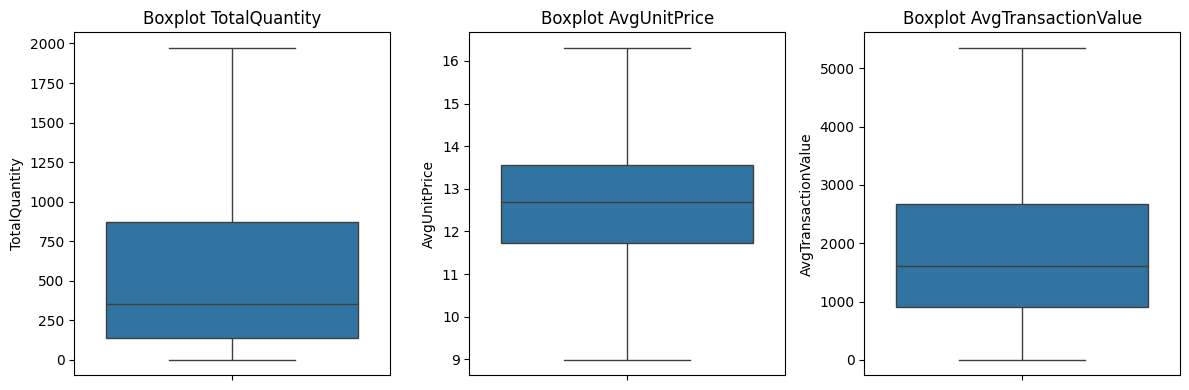

In [ ]:
# --- Visualisasi Distribusi dan Outlier ---
plt.figure(figsize=(12, 4))
for i, col in enumerate(X.columns):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=X[col])
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

# Standardisasi Fitur Menggunakan StandardScaler

In [ ]:
# Scaling Data menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Buat DataFrame dari data scaled
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nData berhasil di-scaling (Siap untuk Clustering):")
print(df_scaled.head())


Data berhasil di-scaling (Siap untuk Clustering):
   TotalQuantity  AvgUnitPrice  AvgTransactionValue
0      -0.817776      1.036689            -0.316418
1      -0.987583     -0.134645            -1.373598
2      -0.349972      0.540935             2.276980
3      -0.985919      2.366714            -1.341417
4      -0.967606     -1.218223            -1.284771


# Penerapan Elbow Method untuk Menentukan Jumlah Cluster (K) Optimal

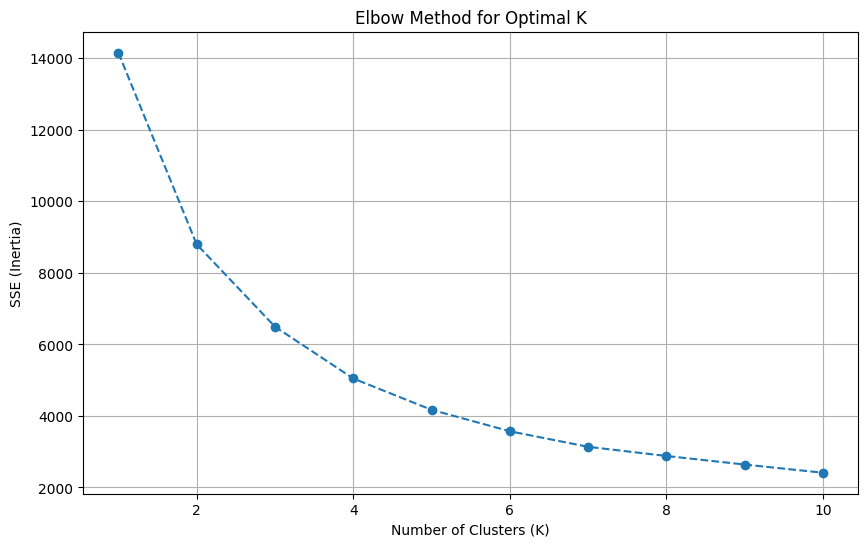

In [ ]:
# Elbow Method
sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    sse[k] = kmeans.inertia_

# Plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(list(sse.keys()), list(sse.values()), marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.grid(True)
plt.show()

# Evaluasi Jumlah Cluster Optimal Menggunakan Silhouette Score

In [ ]:
# Silhouette Score
silhouette_scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores[k] = silhouette_avg

# Tampilkan Silhouette Scores
print("\nSilhouette Scores per K:")
print(silhouette_scores)

# Penghitungan Average Silhouette Score
average_silhouette_score = np.mean(list(silhouette_scores.values()))

# Tampilkan Average Silhouette Score
print("\n---")
print("Rata-rata (Average) Keseluruhan Silhouette Score:")
print(f"Average Silhouette Score (K=2 hingga K=10): {average_silhouette_score:.4f}")


Silhouette Scores per K:
{2: np.float64(0.38551519701093545), 3: np.float64(0.3187334507612524), 4: np.float64(0.3408996948178467), 5: np.float64(0.3198712356305417), 6: np.float64(0.3269335002979968), 7: np.float64(0.31497711399535167), 8: np.float64(0.3134715729045041), 9: np.float64(0.2957627506606573), 10: np.float64(0.30369567466957165)}

---
Rata-rata (Average) Keseluruhan Silhouette Score:
Average Silhouette Score (K=2 hingga K=10): 0.3244


In [ ]:
# Berdasarkan hasil evaluasi
K_optimal = 4 # Ganti sesuai hasil plot dan skor Anda
print(f"\nMemilih K optimal: K = {K_optimal}")


Memilih K optimal: K = 4


# Penerapan K-Means dan Profiling Segmen Pelanggan

In [ ]:
# K-Means
kmeans = KMeans(n_clusters=K_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Gabungkan hasil klaster dengan data fitur asli (Non-RFM)
df_non_rfm['Cluster'] = clusters
df_non_rfm['Cluster'] = df_non_rfm['Cluster'].astype('category')

# Analisis Statistik Klaster (Profiling)
cluster_profile = (
    df_non_rfm
        .groupby('Cluster', observed=False)[['TotalQuantity', 'AvgTransactionValue', 'AvgUnitPrice']]
        .mean()
        .reset_index()
)

print("\n--- Profil Segmen Pelanggan (Rata-rata Fitur per Klaster) ---")
print(cluster_profile.sort_values(by='Cluster'))


--- Profil Segmen Pelanggan (Rata-rata Fitur per Klaster) ---
  Cluster  TotalQuantity  AvgTransactionValue  AvgUnitPrice
0       0     657.776675          3932.500991     12.961870
1       1     332.176568          1223.698162     10.949439
2       2     240.886792          1148.847794     13.757336
3       3    1690.700592          2881.921328     12.032701


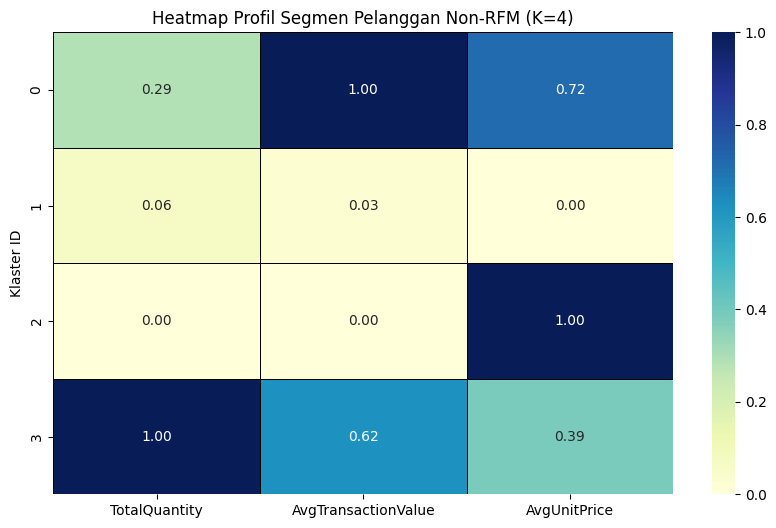

In [ ]:
# Normalisasi Profil untuk Heatmap (Scaling antara 0 dan 1)
scaler_profile = MinMaxScaler()
cluster_profile_for_heatmap = cluster_profile.set_index('Cluster')[['TotalQuantity', 'AvgTransactionValue', 'AvgUnitPrice']]
cluster_profile_scaled = pd.DataFrame(scaler_profile.fit_transform(cluster_profile_for_heatmap),
                                      columns=cluster_profile_for_heatmap.columns,
                                      index=cluster_profile_for_heatmap.index)

# Visualisasi Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile_scaled,
            annot=True,
            cmap='YlGnBu',
            fmt=".2f",
            linewidths=.5,
            linecolor='black')
plt.title(f'Heatmap Profil Segmen Pelanggan Non-RFM (K={K_optimal})')
plt.ylabel('Klaster ID')
plt.show()

# Reduksi Dimensi (PCA) dan Visualisasi Klaster 3D Interaktif

In [ ]:
# PCA untuk Mereduksi Dimensi menjadi 3 Komponen ----
pca = PCA(n_components=3)
principal_components = pca.fit_transform(df_scaled)
pca_df = pd.DataFrame(
    principal_components,
    columns=['Principal_Component_1', 'Principal_Component_2', 'Principal_Component_3']
)

# Tambahkan label klaster ke hasil PCA
pca_df['Cluster'] = df_non_rfm['Cluster'].values.astype(str)

# Transformasi Centroid ke Ruang PCA ----
centroids_scaled = kmeans.cluster_centers_                     # centroid di ruang scaled
centroids_df = pd.DataFrame(centroids_scaled, columns=df_scaled.columns)
centroids_pca = pca.transform(centroids_df)                    # ubah centroid ke ruang PCA

centroid_df = pd.DataFrame(
    centroids_pca,
    columns=['Principal_Component_1', 'Principal_Component_2', 'Principal_Component_3']
)
centroid_df['Cluster'] = [f'Centroid {i}' for i in range(len(centroids_pca))]

# Plot 3D Interaktif dengan Plotly ----
fig = go.Figure()

# Plot titik data setiap klaster
for cluster in sorted(pca_df['Cluster'].unique(), key=lambda x: int(x)):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]
    fig.add_trace(go.Scatter3d(
        x=cluster_data['Principal_Component_1'],
        y=cluster_data['Principal_Component_2'],
        z=cluster_data['Principal_Component_3'],
        mode='markers',
        marker=dict(size=4, opacity=0.75),
        name=f'Cluster {cluster}'
    ))

# Plot centroid (titik X berwarna merah)
fig.add_trace(go.Scatter3d(
    x=centroid_df['Principal_Component_1'],
    y=centroid_df['Principal_Component_2'],
    z=centroid_df['Principal_Component_3'],
    mode='markers',
    marker=dict(size=12, symbol='x', color='red'),
    name='Centroid'
))

# Pengaturan Axis, Judul, dan Ukuran Layout ----
explained_var = pca.explained_variance_ratio_ * 100
fig.update_layout(
    title=f'Visualisasi Klaster K-Means (K={K_optimal}) menggunakan PCA (3D Interaktif)',
    scene=dict(
        xaxis_title=f'PC1 ({explained_var[0]:.2f}% Variance)',
        yaxis_title=f'PC2 ({explained_var[1]:.2f}% Variance)',
        zaxis_title=f'PC3 ({explained_var[2]:.2f}% Variance)',
    ),
    legend_title="Klaster",
    width=1050, height=720
)

# Menampilkan jumlah baris dalam pca_df, yaitu total jumlah customer/observasi
# yang digunakan dalam analisis PCA dan clustering
print(f"Total Jumlah Data: {len(pca_df)}")

# Menampilkan Plot (interaktif — bisa rotate / zoom) ----
fig.show()

Total Jumlah Data: 4718


In [ ]:
# Analisis Deskriptif Rinci per Klaster
cluster_description = df_non_rfm.groupby('Cluster', observed=True)[['TotalQuantity', 'AvgTransactionValue', 'AvgUnitPrice']].describe()

print(f"\n--- Statistik Deskriptif Rinci Klaster (K={K_optimal}) ---")
print(cluster_description)


--- Statistik Deskriptif Rinci Klaster (K=4) ---
        TotalQuantity                                                   \
                count         mean         std    min      25%     50%   
Cluster                                                                  
0               806.0   657.776675  326.789605  215.0   399.25   598.0   
1              1212.0   332.176568  280.287867    1.0   114.00   240.0   
2              1855.0   240.886792  232.426439    1.0    79.00   156.0   
3               845.0  1690.700592  321.224348  939.0  1402.00  1855.0   

                         AvgTransactionValue               ...               \
             75%     max               count         mean  ...          75%   
Cluster                                                    ...                
0         869.25  1780.0               806.0  3932.500991  ...  5062.787500   
1         488.50  1395.0              1212.0  1223.698162  ...  1715.828125   
2         332.00  1286.0            

# Export Data

In [ ]:
df_non_rfm.to_csv('Hasil_Clustering_Customer.csv', index=False)

cluster_profile.to_csv('Summary_Profil_Cluster.csv', index=False)